In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch

from scipy.stats import skewnorm
from scipy.special import erf
import matplotlib.cm as cm
import matplotlib

from scipy.signal import savgol_filter

from matplotlib.cm import ScalarMappable
import matplotlib
import matplotlib.colors as colors
import pickle


import os 
import sys



In [2]:

# Get the current working directory
current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, ".."))

# Navigate to the sibling directory
sibling_dir = os.path.join(parent_dir, "00_analytical_function_setup")

# Add the sibling directory to sys.path for importing
if sibling_dir not in sys.path:
    sys.path.append(sibling_dir)

# Import the modules from 00_analytical_function_setup
import analytical as a
import search_cost_functions as fun

## Load data

In [3]:

# Loading reference landscape data
with open('data/reference_landscape_reward.pkl', 'rb') as file:
    reference_landscape = pickle.load(file)

# Loading the saved output
with open('data/reference_threshold_vec.pkl', 'rb') as file:
    reference_threshold = pickle.load(file)


In [4]:
reference_threshold 

array([-3.        , -2.81632653, -2.63265306, -2.44897959, -2.26530612,
       -2.08163265, -1.89795918, -1.71428571, -1.53061224, -1.34693878,
       -1.16326531, -0.97959184, -0.79591837, -0.6122449 , -0.42857143,
       -0.24489796, -0.06122449,  0.12244898,  0.30612245,  0.48979592,
        0.67346939,  0.85714286,  1.04081633,  1.2244898 ,  1.40816327,
        1.59183673,  1.7755102 ,  1.95918367,  2.14285714,  2.32653061,
        2.51020408,  2.69387755,  2.87755102,  3.06122449,  3.24489796,
        3.42857143,  3.6122449 ,  3.79591837,  3.97959184,  4.16326531,
        4.34693878,  4.53061224,  4.71428571,  4.89795918,  5.08163265,
        5.26530612,  5.44897959,  5.63265306,  5.81632653,  6.        ])

In [5]:

# df_uniform_group_hist = pd.read_csv('data/Reward_Cumulative_20240607060823_group_hist.csv')
# threshold_vec_group,corr_val,simresults_uniform_group_hist=a.df_to_simresults(df_uniform_group_hist,num_cols=1)

# df_uniform_upward = pd.read_csv('data/Reward_Cumulative_20241019214552_group_hist_upward.csv')
# threshold_vec_upward,corr_val,simresults_uniform_upward=a.df_to_simresults(df_uniform_upward,num_cols=1)




## Compute expected reward with search cost

In [32]:
threshold_vec = np.linspace(reference_threshold[0], reference_threshold[-1], 10**4)
tmax = 1000
sigma = 1.0
c = 500


with_cost = fun.cumulative_sum_with_cost(reference_threshold, tmax, sigma, c)

# Now you can plot no_cost vs with_cost just like in Mathematica
# (e.g., with matplotlib)


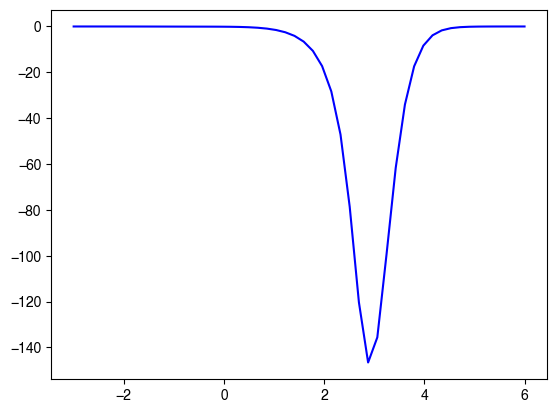

In [33]:
plt.plot(reference_threshold, with_cost, label='With Search Cost', color='blue')

## Plotting

In [29]:

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [23]:
# Custom black color
myblack = "#222222"
myaccent=myblack
mediumgrey='#abadaa'
lightgrey="#D3D3D3"
warmorange='#f5c72f'
softpurple="#a489f5"
# Set font globally
matplotlib.rcParams['font.family'] = 'Helvetica, Arial, sans-serif'
matplotlib.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'  # Fallback to Arial if Helvetica is not available
dpi=300

In [24]:
# num_curves1 = simresults_uniform_group_hist.shape[1]
# num_curves2 = simresults_uniform_upward.shape[1]

# # Create a figure with two subplots side by side
# fig = plt.figure(figsize=(4, 4), dpi=100)

# # Define colormap
# cmap = truncate_colormap(plt.get_cmap('Greens_r'), 0., 0.8)
# norm = plt.Normalize(vmin=0, vmax=num_curves1-1)
# sm = ScalarMappable(norm=norm, cmap=cmap)

# # Define two colormaps
# cmap_before = truncate_colormap(plt.get_cmap('Blues_r'), 0, 0.8)
# cmap_after = truncate_colormap(plt.get_cmap('Reds'), 0.2, 1)

# # Normalization for each segment
# norm_before = plt.Normalize(vmin=0, vmax=5)
# norm_after = plt.Normalize(vmin=0, vmax=num_curves2-7)

# # ScalarMappable instances for each segment
# sm_before = ScalarMappable(norm=norm_before, cmap=cmap_before)
# sm_after = ScalarMappable(norm=norm_after, cmap=cmap_after)

# group_hist_optimum = np.zeros(num_curves1)
# upward_optimum = np.zeros(num_curves1)
# for j in range(num_curves1):
#     group_hist_optimum[j] = threshold_vec_group[np.argmax(simresults_uniform_group_hist[:, j])]
#     upward_optimum[j] = threshold_vec_upward[np.argmax(simresults_uniform_upward[:, j])]

# # First subplot
# ax1 = fig.add_subplot(1, 1, 1)

# color1 = warmorange
# color2 = softpurple

# # Plot lines with labels for legend - using unfiltered data
# line1, = ax1.plot(threshold_vec_group, simresults_uniform_group_hist[:, 0], color=color1, linewidth=2, 
#                   label='All-cohort')
# ax1.scatter(group_hist_optimum[0], max(simresults_uniform_group_hist[:, 0]), 
#             color=color1, marker='o', s=25)

# line2, = ax1.plot(threshold_vec_upward, simresults_uniform_upward[:, 0], color=color2, 
#                   linewidth=2, label='Upward')
# ax1.scatter(upward_optimum[0], max(simresults_uniform_upward[:, 0]), 
#             color=color2, marker='o', s=25)

# line3, = ax1.plot(reference_threshold, reference_landscape, linestyle=':', 
#                   color='k', linewidth=2, label='None')


# # Updated legend formatting
# ax1.legend(handles=[line1, line2, line3],
#           frameon=False, 
#           loc='upper center',
#           bbox_to_anchor=(0.5, -0.61),
#           ncol=1)

# ax1.set_xlabel('Satisfaction threshold', fontsize=10, color=myblack)
# ax1.set_title('Social comparison', fontsize=12, color=myblack)
# ax1.set_ylabel("Expected reward per time step", fontsize=10, color=myblack)
# ax1.tick_params(colors=myblack)
# ax1.set_xlim(-3, 4)
# ax1.set_xticks([-2, 0, 2, 4])
# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
# for spine in ax1.spines.values():
#     spine.set_color(myblack)

# plt.tight_layout()
# plt.savefig('output/figure_6_with_legend.pdf', format='pdf', bbox_inches='tight')
# plt.show()

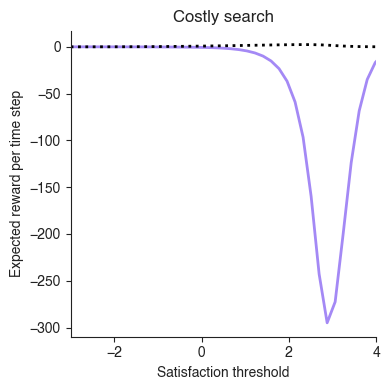

In [26]:
# assumes you already have:
# reference_threshold, reference_landscape
# with_cost = fun.cumulative_sum_with_cost(reference_threshold, tmax, sigma, c)

import numpy as np
import matplotlib.pyplot as plt

# choose a color for the with_cost curve (reuse one of your palette vars if you like)
color_cost = softpurple if 'softpurple' in globals() else 'tab:purple'

# find the maximizing threshold for with_cost
i_star = int(np.nanargmax(with_cost))
x_star = reference_threshold[i_star]
y_star = with_cost[i_star]

# figure
fig = plt.figure(figsize=(4, 4), dpi=100)
ax1 = fig.add_subplot(1, 1, 1)

# with-cost curve + its optimum
line_cost, = ax1.plot(
    reference_threshold, with_cost,
    color=color_cost, linewidth=2, label=f'With cost c={c}'
)
ax1.scatter(x_star, y_star, color=color_cost, marker='o', s=25, zorder=5)

# reference landscape (unchanged)
line_ref, = ax1.plot(
    reference_threshold, reference_landscape,
    linestyle=':', color='k', linewidth=2, label='None'
)

# legend (keeps your formatting/location)
# ax1.legend(
#     handles=[line_cost, line_ref],
#     frameon=False,
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.61),
#     ncol=1
# )

# axes & styling (kept from your snippet)
ax1.set_xlabel('Satisfaction threshold', fontsize=10, color=myblack)
ax1.set_title('Costly search', fontsize=12, color=myblack)
ax1.set_ylabel('Expected reward per time step', fontsize=10, color=myblack)
ax1.tick_params(colors=myblack)
ax1.set_xlim(-3, 4)
ax1.set_xticks([-2, 0, 2, 4])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for spine in ax1.spines.values():
    spine.set_color(myblack)

plt.tight_layout()
plt.savefig('output/figure_6_with_legend.pdf', format='pdf', bbox_inches='tight')
plt.show()
